# FoodSure AI — Exploratory Data Analysis

## Project
AI-Based Turmeric Adulteration Detection and Quantification

## Objective
This notebook performs exploratory data analysis on the multimodal turmeric adulteration dataset.

The dataset contains controlled turmeric samples adulterated with wheat flour at seven levels:

- 0%
- 1%
- 2%
- 3%
- 5%
- 7%
- 9%

## Modalities

The dataset contains three primary modalities:

1. **Image** — RGB images of turmeric samples
2. **FTIR Spectroscopy** — spectral measurements across wavenumbers
3. **Color Measurement** — Hunter Lab values and wavelength-based measurements

## EDA Goals

The purpose of this notebook is to understand:

- distributions of the target classes
- relationships between adulteration level and measured features
- FTIR spectral patterns
- color variation across adulteration levels
- image-feature distributions
- potential outliers and unusual observations
- separability between adulteration classes

No machine-learning model is trained in this notebook.

In [1950]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [1951]:
# Dataset paths

ftir_path = "../Dataset/FTIR Spectroscopy/FTIR_Data.csv"

color_path = "../Dataset/Color Measurement/Hunter_Lab_colorimeter.csv"

efficientnet_path = (
    "../Dataset/Image/"
    "EfficientNetB0_Image_Features/"
    "EfficientNetB0_Image_Features.csv"
)

# Load datasets
ftir = pd.read_csv(ftir_path)
color = pd.read_csv(color_path)
efficientnet = pd.read_csv(efficientnet_path)

print("FTIR shape:", ftir.shape)
print("Color shape:", color.shape)
print("EfficientNet shape:", efficientnet.shape)

FTIR shape: (350, 2525)
Color shape: (350, 48)
EfficientNet shape: (350, 1282)


## 2. Target Variable Distribution

The target variable represents the percentage of wheat-flour adulteration in each turmeric sample.

The dataset contains seven controlled adulteration levels:

0%, 1%, 2%, 3%, 5%, 7%, and 9%.

Before examining individual features, we verify the class distribution because class imbalance can affect model training and evaluation.

In [1952]:
target_distribution = color["Target"].value_counts().sort_index()

print(target_distribution)

Target
0%    50
1%    50
2%    50
3%    50
5%    50
7%    50
9%    50
Name: count, dtype: int64


### Interpretation

The target distribution will be examined to determine whether the dataset is balanced across the seven adulteration levels.

A balanced distribution is useful because it reduces the risk that a classification model becomes biased toward a majority class.

## 4. Color Measurement Analysis

The color modality contains three Hunter Lab measurements:

- **L\*** — lightness
- **a\*** — red/green component
- **b\*** — yellow/blue component

These measurements are analyzed across the seven adulteration levels to investigate whether wheat-flour adulteration produces measurable changes in the visual color properties of turmeric.

The analysis begins with group-level statistics before moving to distributions and relationships.

In [1953]:
# Create a numerical representation of adulteration percentage
color["Adulteration_Percent"] = (
    color["Target"]
    .str.replace("%", "")
    .astype(float)
)

print(color[["Target", "Adulteration_Percent"]].head())

  Target  Adulteration_Percent
0     0%                   0.0
1     0%                   0.0
2     0%                   0.0
3     0%                   0.0
4     0%                   0.0


### 4.1 Mean Color Measurements by Adulteration Level

The mean of each color measurement is calculated for every adulteration level.

This provides an initial overview of how the average color properties change as the amount of wheat flour increases.

In [1954]:
lab_means = (
    color.groupby("Adulteration_Percent")[["L*", "a*", "b*"]]
    .mean()
)

print(lab_means)

                           L*       a*       b*
Adulteration_Percent                           
0.0                   62.7856  23.2140  45.4562
1.0                   63.9582  22.4260  46.9692
2.0                   64.4280  22.3484  46.8374
3.0                   64.8518  21.8504  47.6246
5.0                   65.5802  21.6596  47.9296
7.0                   65.7570  21.0784  48.5468
9.0                   66.2524  20.8826  49.0002


### 4.2 Mean Color Trends

The following visualization shows how the average L\*, a\*, and b\* measurements vary across adulteration levels.

The purpose is to identify broad trends before examining sample-level variability.

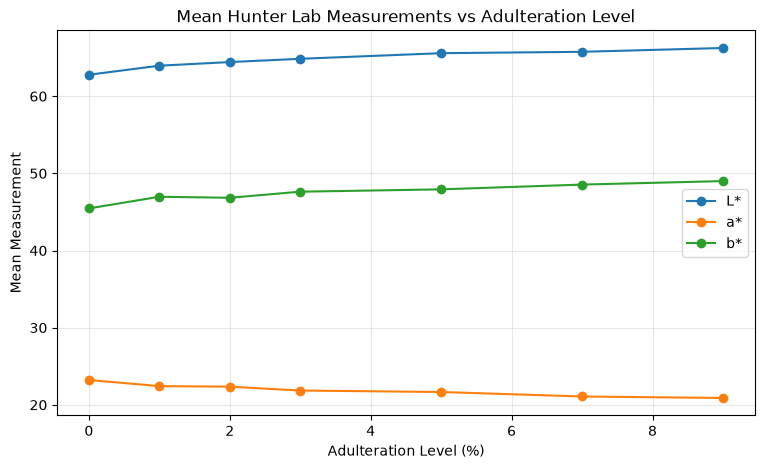

In [1955]:
plt.figure(figsize=(9, 5))

for feature in ["L*", "a*", "b*"]:
    plt.plot(
        lab_means.index, # (the adulteration percentages) as the horizontal X-axis values.
        lab_means[feature], #Pulls the average value for the current color dimension to plot on the vertical Y-axis.
        marker="o",
        label=feature #Assigns a label (e.g., "L*") to each line so it can be identified in the plot legend.
    )

plt.xlabel("Adulteration Level (%)")
plt.ylabel("Mean Measurement")
plt.title("Mean Hunter Lab Measurements vs Adulteration Level")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

From the graph:

1. L* increases gradually as adulteration increases.
The turmeric samples become slightly lighter on average.
2. a* decreases gradually.
This indicates a reduction in the red component as wheat flour adulteration increases.
3. b* increases gradually.
This indicates an increase in the yellow component in this dataset.

### 4.3 Distribution of Hunter Lab Measurements

Mean values provide an overview of the overall trend, but they do not show the variability within each adulteration level.

To examine the spread and overlap of individual samples, we visualize the distributions of L*, a*, and b* using boxplots.

Boxplots allow us to compare:

- median values
- interquartile ranges
- overall spread
- potential outliers
- overlap between adulteration levels

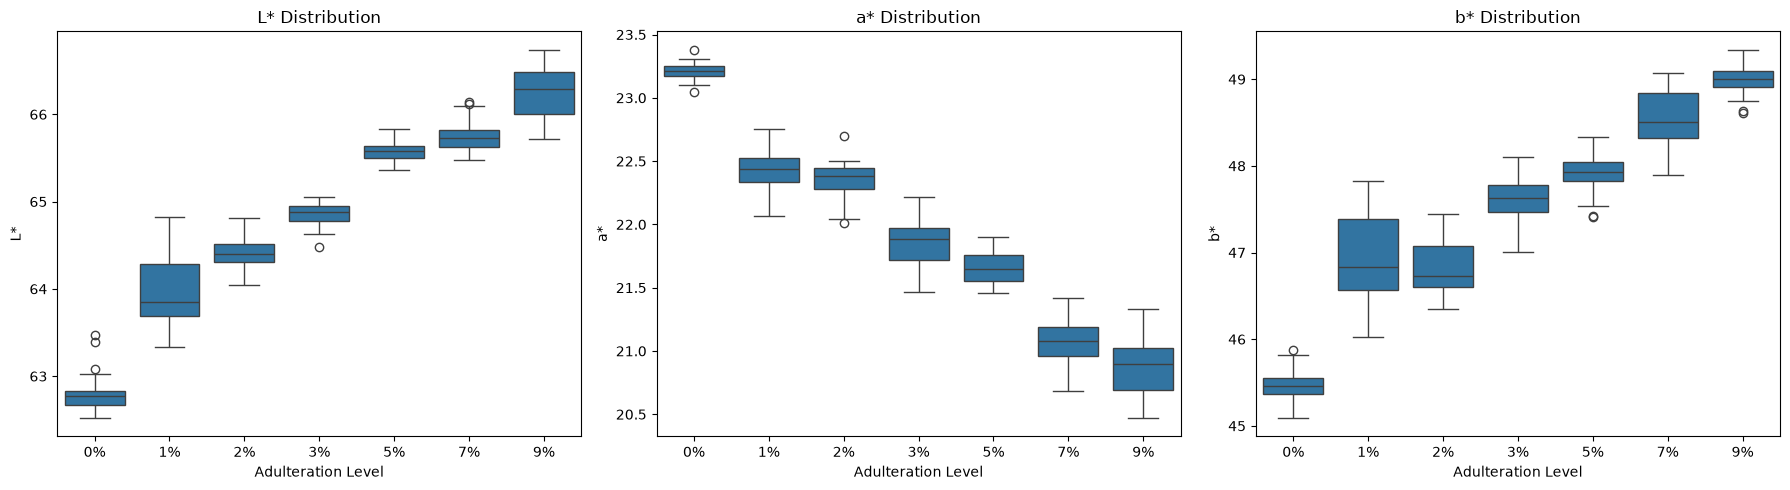

In [1956]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["L*", "a*", "b*"]

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=color, # Specifies the source DataFrame (color).
        x="Target",
        y=feature,
        order=["0%", "1%", "2%", "3%", "5%", "7%", "9%"],
        ax=ax # Directs Seaborn to render the current boxplot inside the specific subplot panel assigned to this loop step.
    )

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel("Adulteration Level")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

🧪 4.3 Interpretation — Hunter Lab Distributions
L* — Lightness

From 0% → 9% adulteration, the median L* generally increases.

0% has the lowest L* values.
The distributions shift upward as adulteration increases.
There is some overlap, particularly around the lower adulteration levels.
A few outliers are visible, especially at 0% and 7%.

Observation: L* appears to contain useful information about adulteration level, but the boxplots alone do not establish classification performance.

a* — Red/Green Component

The a* measurement shows a fairly clear decreasing trend.

0% has the highest median.
The median progressively decreases toward 9%.
The distributions of neighboring classes still show some overlap.
The overall downward movement is relatively consistent.

Observation: a* appears to have a strong relationship with adulteration percentage in this dataset.

b* — Yellow/Blue Component

The b* measurement generally increases with adulteration.

0% has the lowest median.
Higher adulteration levels tend to have higher b* values.
1%, 2%, and some neighboring levels show noticeable overlap.
At higher levels such as 5%, 7%, and 9%, the distributions appear more separated.

Observation: b* also shows a relationship with adulteration, although the amount of overlap varies between classes.

4.4 Correlation Between Color Features and Adulteration

### 4.4 Correlation Between Color Measurements and Adulteration

The boxplots showed systematic changes in L*, a*, and b* across adulteration levels.

To quantify these relationships, we calculate the Pearson correlation between the numerical adulteration percentage and each Hunter Lab measurement.

Correlation measures the strength and direction of a linear relationship:

- values close to +1 indicate a strong positive relationship
- values close to -1 indicate a strong negative relationship
- values close to 0 indicate a weak linear relationship

Correlation does not imply causation and does not by itself measure classification performance.

In [1957]:
# Calculate correlation between adulteration percentage and Hunter Lab features

correlation = color[
    ["Adulteration_Percent", "L*", "a*", "b*"]
].corr()

print(correlation)

                      Adulteration_Percent        L*        a*        b*
Adulteration_Percent              1.000000  0.925670 -0.943219  0.911491
L*                                0.925670  1.000000 -0.967480  0.960005
a*                               -0.943219 -0.967480  1.000000 -0.958357
b*                                0.911491  0.960005 -0.958357  1.000000


🧠 What does this tell us?
L* (+0.9257): strong positive linear relationship — L* generally increases as adulteration percentage increases.
a* (−0.9432): strong negative linear relationship — a* generally decreases as adulteration increases.
b* (+0.9115): strong positive linear relationship — b* generally increases as adulteration increases.

So all three Hunter Lab measurements show a strong linear association with the adulteration percentage in this dataset.

The strongest absolute correlation among the three is a* (|r| ≈ 0.943), followed by L* and b*.

### 4.5 Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between adulteration percentage and the Hunter Lab measurements.

This helps us quickly identify the direction and strength of the relationships observed in the correlation matrix.

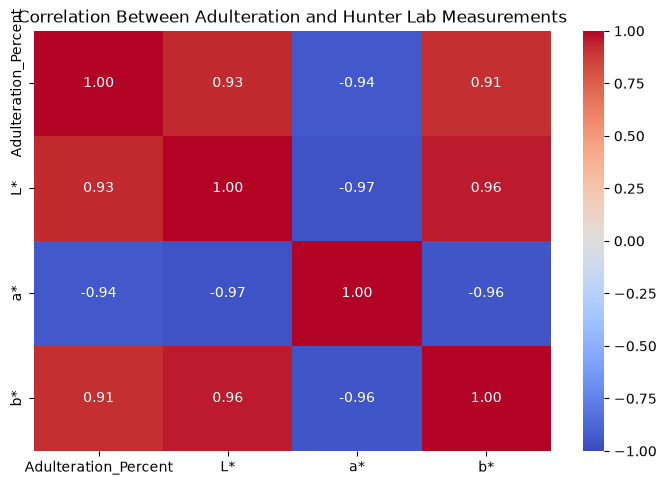

In [1958]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,#The input DataFrame or 2D matrix containing linear correlation coefficients (Pearson/Spearman) between variables.
    annot=True, #Annotates each grid cell by printing its numerical correlation value directly inside the square.
    cmap="coolwarm",
    fmt=".2f", # Formats the printed numerical labels to 2 decimal places
    vmin=-1,
    vmax=1 # Fixes the minimum and maximum bounds of the color scale bar to -1.0 and +1.0, ensuring standard interpretation of correlation coefficients.
)

plt.title("Correlation Between Adulteration and Hunter Lab Measurements")
plt.tight_layout()

plt.show()

4.6 Analyze the 43 Wavelength Features

### 4.6 Wavelength-Based Color Measurements

In addition to the Hunter Lab measurements, the color dataset contains measurements across wavelengths from 360 nm to 780 nm.

These wavelength-based features provide more detailed information about the optical characteristics of the turmeric samples.

We examine the average wavelength profile for each adulteration level to determine

In [1959]:
# Identify wavelength columns
wavelength_columns = [
    col for col in color.columns
    if str(col).replace(".", "", 1).isdigit() #.replace(".", "", 1): Replaces the first occurrence of a decimal point with an empty string. This allows decimal string numbers (e.g., "400.5") to be evaluated properly alongside whole integers (e.g., "400").
]

print("Number of wavelength features:", len(wavelength_columns))
print("Wavelength range:", wavelength_columns[0], "to", wavelength_columns[-1])

Number of wavelength features: 43
Wavelength range: 360 to 780


### 4.6.1 Mean Wavelength Profile by Adulteration Level

For each wavelength, we calculate the mean measurement separately for each adulteration level.

This produces an average wavelength profile for every class.

Comparing these profiles helps us identify wavelength regions where the optical response of turmeric changes with increasing wheat flour adulteration.

In [1960]:
# Calculate mean wavelength measurements for each adulteration level

wavelength_means = (
    color.groupby("Adulteration_Percent")[wavelength_columns]
    .mean()
)

print(wavelength_means)

                         360     370     380     390     400     410     420  \
Adulteration_Percent                                                           
0.0                   8.6916  8.6850  8.4734  8.6652  8.7676  8.7962  8.8392   
1.0                   8.8146  8.7980  8.4948  8.6902  8.7778  8.7912  8.8382   
2.0                   8.9872  8.9508  8.8934  8.9816  9.0924  9.1194  9.1574   
3.0                   9.0796  9.0404  8.8752  8.9900  9.0560  9.0534  9.0912   
5.0                   9.2942  9.2660  9.0800  9.2428  9.3032  9.3082  9.3324   
7.0                   9.2286  9.1702  8.9678  9.0894  9.1384  9.1134  9.1334   
9.0                   9.2752  9.2118  9.0290  9.1256  9.1672  9.1330  9.1534   

                         430     440     450  ...      690      700      710  \
Adulteration_Percent                          ...                              
0.0                   8.8812  8.9668  9.0702  ...  64.3802  65.6974  67.0576   
1.0                   8.8940  8.9942  9

### 4.6.2 Mean Wavelength Profiles

The mean wavelength measurements are visualized for all seven adulteration levels.

Each line represents the average wavelength profile of one adulteration level.

This visualization helps us identify:

- overall differences between adulteration levels
- wavelength regions where the profiles separate
- whether the relationship is consistent across the spectrum
- regions that may contain useful information for later modeling

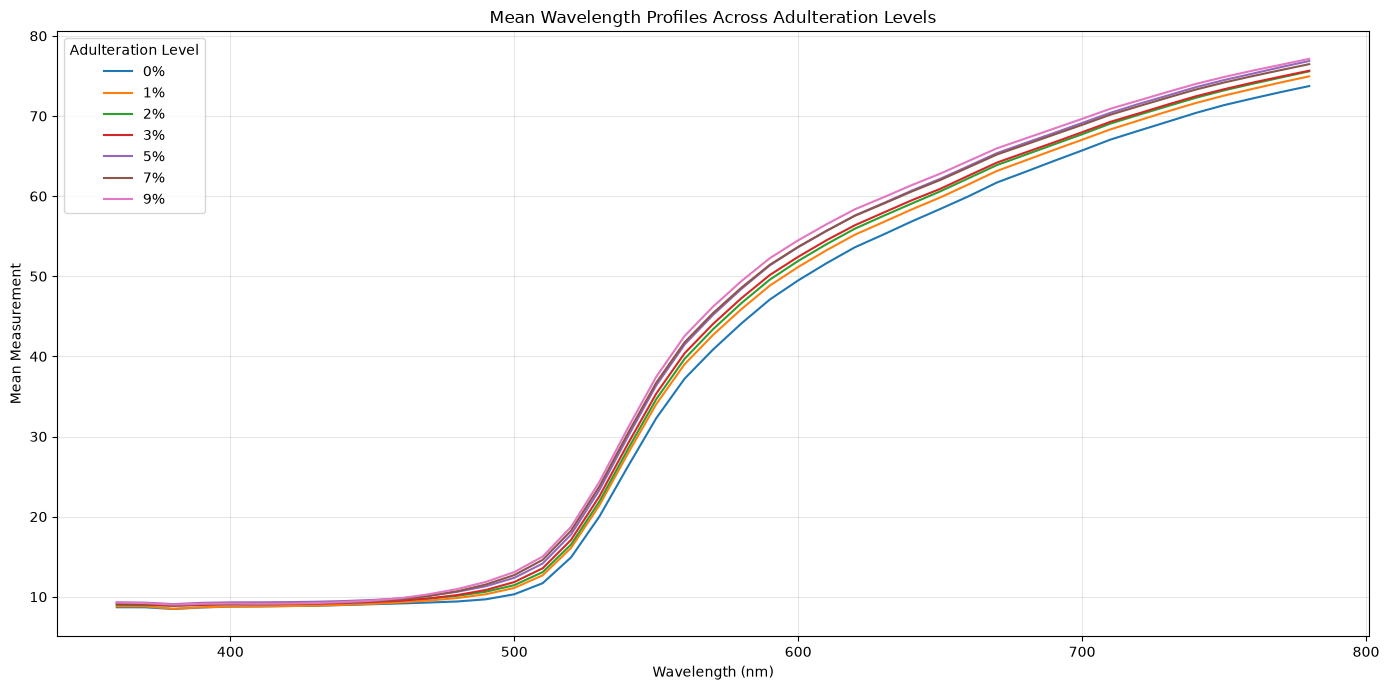

In [1961]:
plt.figure(figsize=(14, 7))

for level in wavelength_means.index: #Iterates through each unique adulteration level (the row index of the wavelength_means DataFrame).
    plt.plot(
        wavelength_means.columns.astype(float),#Converts the column names (the spectral wavelengths) into numeric floating-point values so they plot accurately in numerical order along the continuous X-axis.
        wavelength_means.loc[level], #Selects the row corresponding to the current adulteration level, providing the Y-axis intensity measurements for each wavelength.
        label=f"{level:g}%"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Measurement")
plt.title("Mean Wavelength Profiles Across Adulteration Levels")

plt.legend(title="Adulteration Level")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

4.6.2 Interpretation — Mean Wavelength Profiles
1. Overall trend

The wavelength measurements generally increase as adulteration percentage increases.

The 0% curve is generally the lowest, while the higher adulteration levels tend to lie progressively above it.

This is consistent with what we observed in the Hunter Lab measurements.

2. Low-wavelength region: ~360–450 nm

The curves are very close together here.

That means this region appears to provide relatively little visual separation between the adulteration levels based on the class means.

360 ─────────────── 450 nm
     curves overlap strongly

We shouldn't conclude that these wavelengths are useless yet—we'll quantify their relationships later.

3. Transition region: ~500–600 nm

This is where the profiles begin separating much more noticeably.

Around the sharp rise in the curves, the differences between adulteration levels become easier to see.

This region therefore looks potentially informative.

4. Higher wavelengths: ~600–780 nm

The separation remains visible across much of this region.

The higher-adulteration curves generally remain above the lower-adulteration curves.

So, visually, the later wavelength region appears to contain substantial class-related variation.

4.6.3 Wavelength–Adulteration Correlation

### 4.6.3 Correlation Between Wavelength Measurements and Adulteration

To quantify the relationship between wavelength measurements and adulteration percentage, we calculate the Pearson correlation coefficient for each wavelength.

This allows us to identify wavelength regions that show stronger positive or negative linear associations with adulteration.

These correlations are exploratory and do not by themselves establish that a wavelength is causally responsible for detecting adulteration or that it will perform well in a predictive model.

In [1962]:
# Calculate correlation of every wavelength with adulteration percentage

wavelength_correlations = {}

for wavelength in wavelength_columns:
    wavelength_correlations[float(wavelength)] = color[
        wavelength
    ].corr(color["Adulteration_Percent"])

wavelength_correlations = pd.Series(wavelength_correlations)

print(wavelength_correlations)

360.0    0.839216
370.0    0.800395
380.0    0.738994
390.0    0.708706
400.0    0.644077
410.0    0.563886
420.0    0.530047
430.0    0.564091
440.0    0.613090
450.0    0.687316
460.0    0.814975
470.0    0.910992
480.0    0.941699
490.0    0.952629
500.0    0.956900
510.0    0.954969
520.0    0.947797
530.0    0.939215
540.0    0.930878
550.0    0.926816
560.0    0.924778
570.0    0.922429
580.0    0.920260
590.0    0.918255
600.0    0.917343
610.0    0.915875
620.0    0.915194
630.0    0.910869
640.0    0.911937
650.0    0.911258
660.0    0.907205
670.0    0.906007
680.0    0.904209
690.0    0.904312
700.0    0.902186
710.0    0.901244
720.0    0.897036
730.0    0.897113
740.0    0.896268
750.0    0.895195
760.0    0.893471
770.0    0.887373
780.0    0.882950
dtype: float64


🔬 What stands out?

The strongest correlations appear around approximately 490–520 nm, with the peak in the displayed values around:

500 nm → r ≈ 0.957

This is a strong exploratory signal.

Interestingly, the relationship is not equally strong at every wavelength. Around 400–430 nm, the correlations are noticeably lower, while the region around 470–600 nm is considerably stronger.

4.6.4 Plot Correlation Across Wavelengths

### 4.6.4 Wavelength Correlation Profile

The correlation coefficients are plotted against wavelength to visualize how strongly different wavelength regions are associated with adulteration percentage.

This helps identify regions of the spectrum with relatively stronger or weaker linear relationships with adulteration.

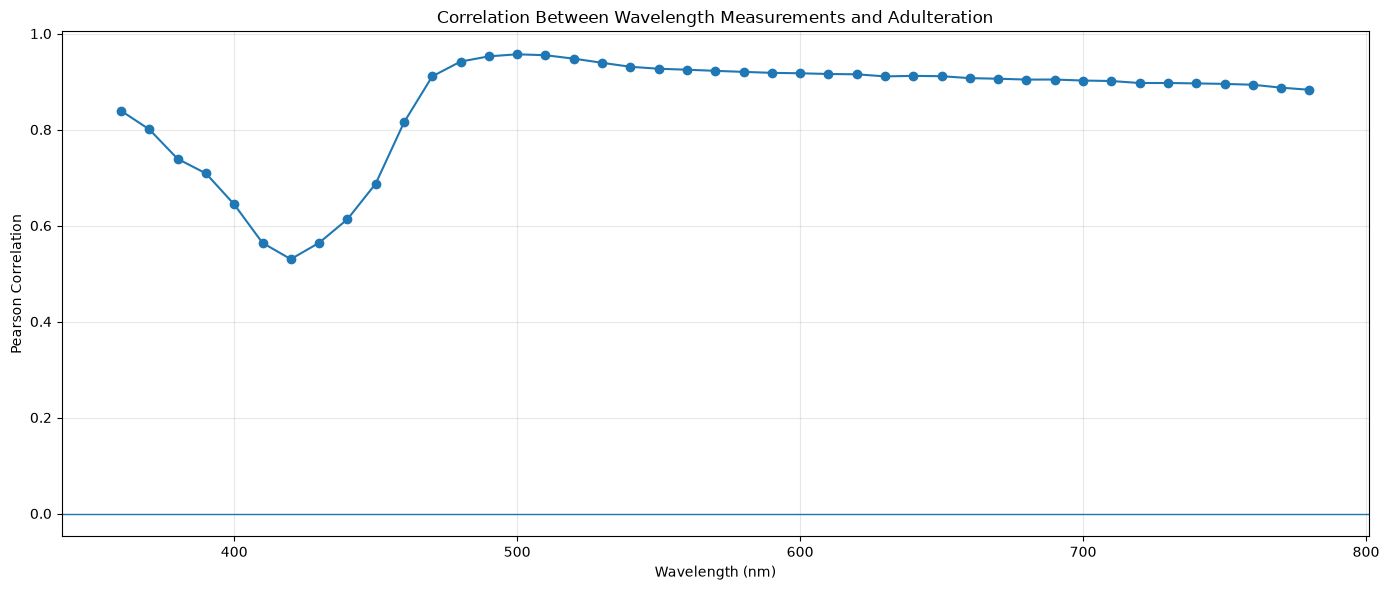

In [1963]:
plt.figure(figsize=(14, 6))

plt.plot(
    wavelength_correlations.index,
    wavelength_correlations.values,
    marker="o"
)

plt.axhline( #Purpose: Makes it easy to visually split positive correlations (above the line) from negative correlations (below the line), as well as identify wavelengths with zero linear correlation.
    0,
    linewidth=1
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Pearson Correlation")
plt.title("Correlation Between Wavelength Measurements and Adulteration")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Key pattern

1. 360–450 nm → weaker relationship

The correlation falls from about 0.84 at 360 nm to roughly 0.53 around 420 nm, then begins increasing.

So this region has comparatively weaker linear association with adulteration.

2. ~460–520 nm → strongest relationship

The correlation rises sharply and reaches its maximum around 500 nm, at approximately 0.96.

This is the most prominent region in our current EDA.

3. ~520–780 nm → consistently strong

After the peak, correlation gradually decreases but remains high—roughly around 0.88–0.95 across much of the remaining spectrum.

### 4.6.5 Top Wavelengths Associated with Adulteration

To identify the wavelength measurements with the strongest linear associations with adulteration percentage, we rank the wavelengths according to the absolute value of their Pearson correlation coefficient.

The top wavelengths are examined as candidate informative regions for later feature engineering and modeling.

These wavelengths are considered exploratory candidates and will require validation during model development.

In [1964]:
# Rank wavelengths by absolute correlation

top_wavelengths = (
    wavelength_correlations
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 wavelengths by absolute correlation:")
print(top_wavelengths)

Top 10 wavelengths by absolute correlation:
500.0    0.956900
510.0    0.954969
490.0    0.952629
520.0    0.947797
480.0    0.941699
530.0    0.939215
540.0    0.930878
550.0    0.926816
560.0    0.924778
570.0    0.922429
dtype: float64


### 4.7 Statistical Significance of Wavelength Correlations

The correlation analysis identified several wavelength regions with strong associations with adulteration percentage.

To further characterize these relationships, Pearson correlation tests are used to calculate the corresponding p-values.

A small p-value indicates that the observed correlation would be unlikely under the null hypothesis of zero linear correlation.

Because multiple wavelengths are tested, these results are considered exploratory and will not be used alone for final feature selection.

In [1965]:
from scipy.stats import pearsonr

wavelength_stats = []

#The intensity measurements for that specific wavelength (color[wavelength]).

#The target variable (color["Adulteration_Percent"]).
for wavelength in wavelength_columns:
    r, p = pearsonr(
        color[wavelength],
        color["Adulteration_Percent"]
    )

    wavelength_stats.append({
        "Wavelength_nm": float(wavelength),
        "Correlation": r, #The correlation coefficient (ranging from -1.0 to +1.0).
        "P_Value": p #The $p$-value (measures statistical significance; values below 0.05 typically indicate statistically significant correlations).
    })

wavelength_stats = pd.DataFrame(wavelength_stats)

print(wavelength_stats.head())

   Wavelength_nm  Correlation       P_Value
0          360.0     0.839216  4.354478e-94
1          370.0     0.800395  2.458377e-79
2          380.0     0.738994  1.175239e-61
3          390.0     0.708706  1.140041e-54
4          400.0     0.644077  2.121142e-42


4.7.1 Top Wavelengths — Correlation + Statistical Significance

### 4.7.1 Top Wavelengths and Their Statistical Significance

The correlation analysis identified a group of wavelengths with strong associations with adulteration percentage.

We now sort the wavelength statistics by the absolute correlation value and examine the corresponding p-values.

This provides a compact summary of the strongest wavelength-level relationships.

In [1966]:
# Sort wavelength statistics by absolute correlation

top_wavelength_stats = (
    wavelength_stats
    .assign(
        Absolute_Correlation=lambda df: df["Correlation"].abs()
    )
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .head(10)
)

print(
    top_wavelength_stats[
        ["Wavelength_nm", "Correlation", "P_Value"]
    ].to_string(index=False)
)

 Wavelength_nm  Correlation       P_Value
         500.0     0.956900 6.044365e-189
         510.0     0.954969 1.046136e-185
         490.0     0.952629 5.731469e-182
         520.0     0.947797 8.200309e-175
         480.0     0.941699 1.065661e-166
         530.0     0.939215 1.216809e-163
         540.0     0.930878 2.995856e-154
         550.0     0.926816 4.306414e-150
         560.0     0.924778 4.271630e-148
         570.0     0.922429 7.292544e-146


4.7.1 Interpretation

All top 10 wavelengths have:

Strong positive correlations with adulteration.
Extremely small p-values (all far below 0.001), indicating strong statistical evidence against a zero Pearson correlation for these individual tests.

For example:

500 nm: r = 0.9569, p ≈ 6.04 × 10⁻¹⁸⁹
510 nm: r = 0.9550
490 nm: r = 0.9526

So the ~480–570 nm region is particularly prominent in this dataset

4.8 Wavelength Feature Redundancy

## 4.8 Wavelength Feature Correlation

The wavelength analysis showed that many wavelengths have strong associations with adulteration percentage.

However, neighboring wavelength measurements may also be highly correlated with one another.

We therefore examine the correlation structure among the wavelength features themselves.

This helps us understand feature redundancy and potential multicollinearity before machine-learning modeling.

In [1967]:
# Calculate correlation between all wavelength features

wavelength_feature_correlation = color[
    wavelength_columns
].corr()

print(wavelength_feature_correlation.shape)

(43, 43)


### 4.8.1 Wavelength Feature Correlation Heatmap

A heatmap is used to visualize correlations between wavelength measurements.

Strong correlations between neighboring wavelengths would indicate that the wavelength features contain substantial redundancy.

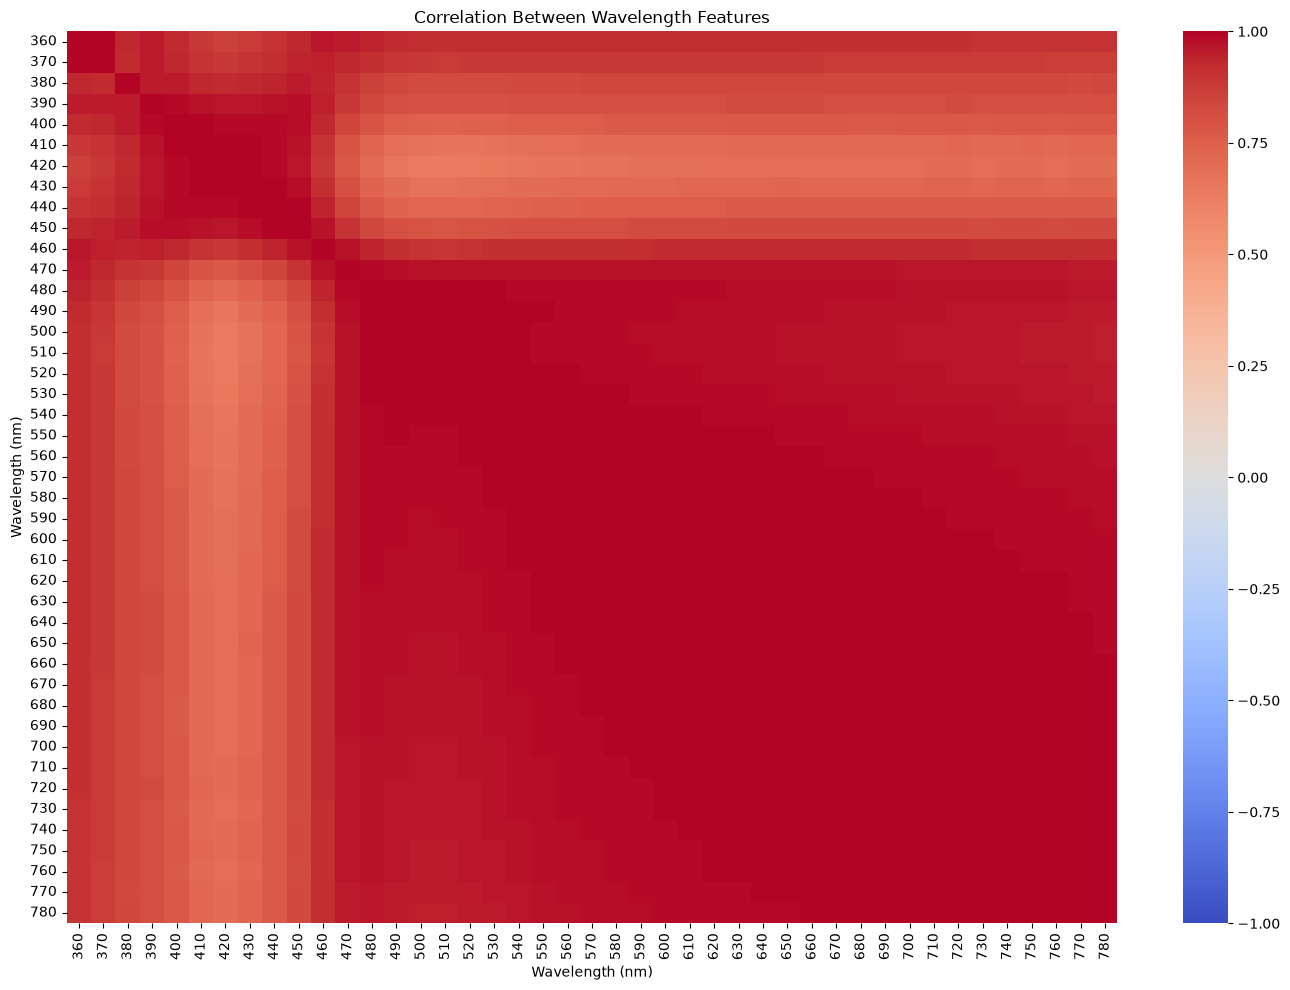

In [1968]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    wavelength_feature_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Wavelength Features")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Wavelength (nm)")

plt.tight_layout()
plt.show()

4.8.1 Interpretation — Wavelength Correlation Heatmap

The dominant red regions indicate strong positive correlations between many wavelength measurements.

What we can observe
Most wavelengths from roughly 480–780 nm are highly correlated with one another.
The wavelengths around 360–450 nm also show substantial correlation, although the structure is somewhat different.
Neighboring wavelengths generally behave similarly.
There are essentially no strong negative-correlation regions in this heatmap.

So our 43 wavelength columns are not 43 independent sources of information.

## 4.9 Outlier Analysis

Outlier analysis is performed to identify observations that differ substantially from the typical measurements within the color dataset.

Potential outliers may represent genuine sample variability or measurement-related variation.

Therefore, outliers are identified for investigation rather than automatically removed.

We first examine the three Hunter Lab measurements because they provide a compact representation of the color characteristics.

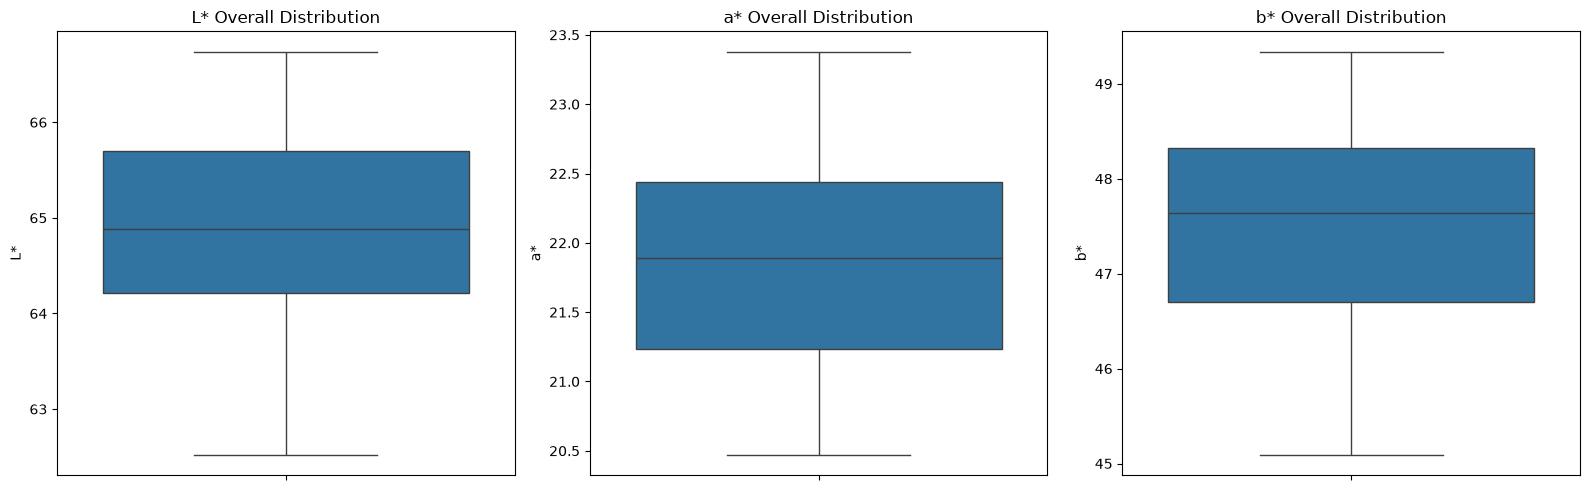

In [1969]:
# Visualize overall distributions of Hunter Lab measurements

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ["L*", "a*", "b*"]

for ax, feature in zip(axes, features):
    sns.boxplot(
        y=color[feature],
        ax=ax
    )

    ax.set_title(f"{feature} Overall Distribution")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

4.9 Interpretation — Overall Lab Outliers

Looking at the three overall boxplots:

L*: no obvious points beyond the whiskers.
a*: no obvious extreme outlier points.
b*: no obvious extreme outlier points.

So, at the overall dataset level, the three Hunter Lab measurements do not show prominent extreme outliers.

This is good because it means we don't currently have an obvious data-quality problem in the Lab measurements.

### 4.9.1 Statistical Outlier Detection Using the IQR Method

The interquartile range (IQR) method is used to identify observations that fall substantially outside the central distribution.

For each Hunter Lab feature:

- Q1 represents the 25th percentile.
- Q3 represents the 75th percentile.
- IQR = Q3 − Q1.
- Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

These observations will be investigated rather than automatically removed.

In [1970]:
# Detect potential outliers using the IQR method

lab_features = ["L*", "a*", "b*"]

outlier_summary = []

for feature in lab_features:
    Q1 = color[feature].quantile(0.25)
    Q3 = color[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (color[feature] < lower_bound) |
        (color[feature] > upper_bound)
    )

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_mask.sum()
    })

outlier_summary = pd.DataFrame(outlier_summary)

print(outlier_summary.to_string(index=False))

Feature      Q1      Q3    IQR  Lower_Bound  Upper_Bound  Outlier_Count
     L* 64.2150 65.6975 1.4825     61.99125     67.92125              0
     a* 21.2325 22.4400 1.2075     19.42125     24.25125              0
     b* 46.7000 48.3250 1.6250     44.26250     50.76250              0


So, using the 1.5 × IQR rule, none of the 350 samples were identified as statistical outliers for the three Hunter Lab measurements.

📌 EDA conclusion

We can therefore document:

No statistical outliers were detected in the Hunter Lab measurements using the IQR method. The color measurements appear reasonably consistent at the overall dataset level, so no outlier removal is required at this stage

---------------------------------------------------------------------------------

## 5. FTIR Spectroscopy Analysis

Fourier Transform Infrared (FTIR) spectroscopy provides a high-dimensional spectral representation of each turmeric sample.

The FTIR dataset contains 2523 spectral measurements for each of the 350 physical samples.

The objective of this analysis is to:

- understand the structure of the FTIR data
- visualize spectral profiles
- compare spectra across adulteration levels
- investigate how spectral measurements change with adulteration
- identify regions that may contain useful information for later modeling

No machine-learning model is trained in this section.

### 5.1 FTIR Dataset Structure

Before analyzing the spectra, we inspect the structure of the FTIR dataset and identify the spectral measurement columns.

The dataset also contains a Sample ID and target information, which are not spectral features.

In [1971]:
print("FTIR shape:", ftir.shape)

print("\nFirst 10 columns:")
print(ftir.columns[:10].tolist())

print("\nLast 10 columns:")
print(ftir.columns[-10:].tolist())

FTIR shape: (350, 2525)

First 10 columns:
['Sample ID', '399.47297', '400.89966', '402.32635', '403.75304', '405.17973', '406.60642', '408.03311', '409.4598', '410.88649']

Last 10 columns:
['3986.16961', '3987.5963', '3989.02299', '3990.44968', '3991.87637', '3993.30306', '3994.72975', '3996.15644', 'Target', 'Unnamed: 2524']


### 5.2 Identifying FTIR Spectral Features

The FTIR dataset contains spectral measurements represented by wavenumbers in cm⁻¹.

We identify the numerical wavenumber columns while excluding the Sample ID and any non-spectral columns.

The resulting feature set will be used for spectral visualization and subsequent FTIR exploratory analysis.

In [1972]:
# Identify FTIR spectral columns

ftir_spectral_columns = []

for col in ftir.columns:
    try:
        float(col) #Attempts to convert each column name (col) into a floating-point number (float(col)).
        ftir_spectral_columns.append(col) #If conversion succeeds, the column is a wavenumber (e.g., "4000.0", "1650.5") and gets added to the list.
    except ValueError:
        pass

print("Number of FTIR spectral features:", len(ftir_spectral_columns))

print(
    "Wavenumber range:",
    float(ftir_spectral_columns[0]),
    "to",
    float(ftir_spectral_columns[-1]),
    "cm⁻¹"
)

Number of FTIR spectral features: 2522
Wavenumber range: 399.47297 to 3996.15644 cm⁻¹


In [1973]:
# Check all FTIR columns that were NOT recognized as numeric

non_numeric_columns = []

for col in ftir.columns:
    try:
        float(col)
    except ValueError:
        non_numeric_columns.append(col)

print("Non-numeric columns:")
print(non_numeric_columns)

print("\nTotal columns:", len(ftir.columns))
print("Numeric spectral columns:", len(ftir_spectral_columns))

Non-numeric columns:
['Sample ID', 'Target', 'Unnamed: 2524']

Total columns: 2525
Numeric spectral columns: 2522


In [1974]:
print("\nFirst 5 spectral columns:")
print(ftir_spectral_columns[:5])

print("\nLast 5 spectral columns:")
print(ftir_spectral_columns[-5:])


First 5 spectral columns:
['399.47297', '400.89966', '402.32635', '403.75304', '405.17973']

Last 5 spectral columns:
['3990.44968', '3991.87637', '3993.30306', '3994.72975', '3996.15644']


### 5.3 Inspecting FTIR Spectral Measurements

Before visualizing the spectra, we inspect a small subset of the FTIR measurements.

This helps verify the numerical range and structure of the spectral data before performing further analysis.

The Sample ID and Target columns are kept separately from the spectral measurements.

In [1975]:
# Inspect the first few FTIR spectral measurements

print(
    ftir[
        ["Sample ID"] + ftir_spectral_columns[:10]
    ].head()
)

  Sample ID  399.47297  400.89966  402.32635  403.75304  405.17973  406.60642  \
0     T0S01   1.037915   1.036230   1.036401   1.037039   1.035914   1.033689   
1     T0S02   1.037610   1.036221   1.036341   1.037780   1.035899   1.035044   
2     T0S03   1.037114   1.036068   1.036403   1.035932   1.035938   1.033783   
3     T0S04   1.036670   1.036074   1.036775   1.036964   1.036054   1.033322   
4     T0S05   1.033297   1.036027   1.037310   1.037565   1.035871   1.033380   

   408.03311  409.4598  410.88649  412.31318  
0   1.029641  1.034977   1.024125   1.029560  
1   1.033415  1.031860   1.030765   1.031331  
2   1.036381  1.030560   1.036050   1.034440  
3   1.035164  1.034887   1.034782   1.034992  
4   1.030104  1.041717   1.032694   1.030060  


The first FTIR measurements are:

numerical floating-point values
around 1.03–1.04 in this region
associated correctly with each Sample ID
ordered by increasing wavenumber

We don't see obvious missing or malformed values in this inspected portion.

### 5.4 FTIR Spectral Profiles

A spectral profile shows how the measured FTIR response changes across wavenumbers for an individual turmeric sample.

We first visualize a small number of representative samples to understand the overall shape and variation of the FTIR spectra.

At this stage, we do not attempt to classify samples or identify adulteration levels. The purpose is to understand the structure of the spectral data before comparing groups.

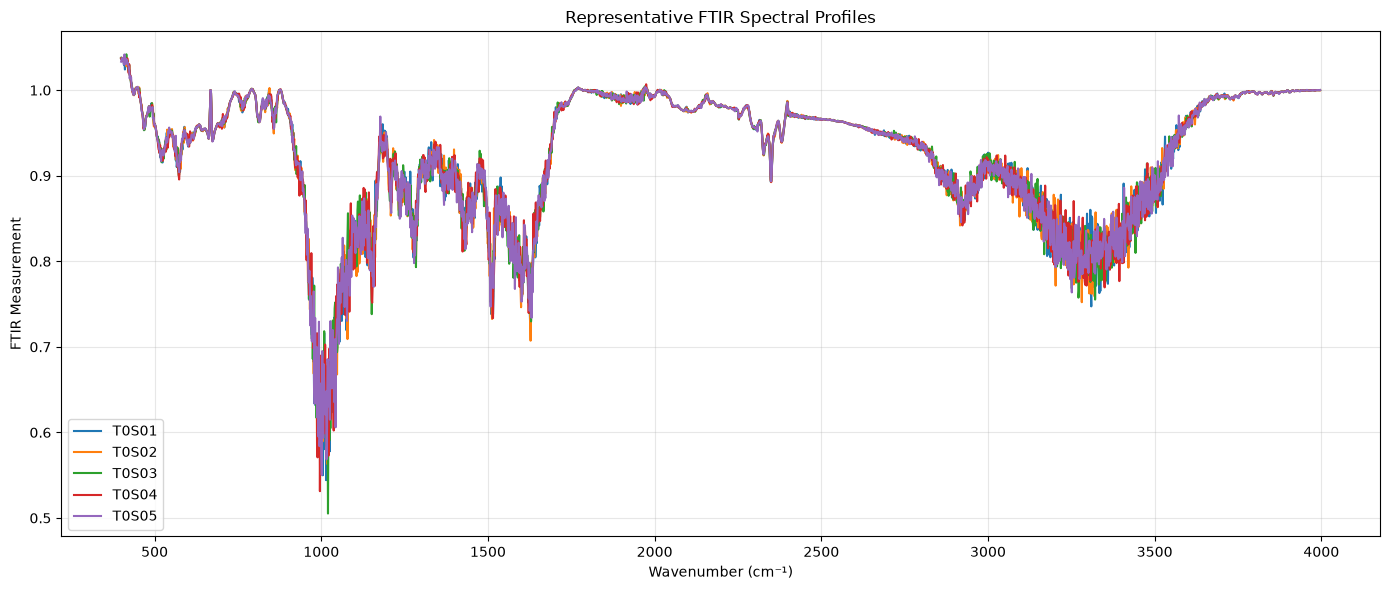

In [1976]:
# Plot FTIR spectra for a few representative samples

wavenumbers = np.array(
    [float(col) for col in ftir_spectral_columns]
)

plt.figure(figsize=(14, 6))

for i in range(5):
    plt.plot(
        wavenumbers,
        ftir.loc[i, ftir_spectral_columns].values,
        label=ftir.loc[i, "Sample ID"]
    )

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("FTIR Measurement")
plt.title("Representative FTIR Spectral Profiles")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A few regions stand out:

1. Around ~1000–1100 cm⁻¹

There is a strong absorption feature, with the FTIR response dropping substantially.

This is one of the most prominent regions in the plotted spectra.

2. ~1200–1700 cm⁻¹

There are several smaller peaks and valleys, showing more detailed spectral structure.

The samples show some variation in this region.

3. ~1800–2500 cm⁻¹

The spectra are comparatively smoother, with smaller variations.

4. ~2800–3500 cm⁻¹

There is another broad region of noticeable variation, with the strongest depression roughly around the 3200–3400 cm⁻¹ region.

5. Sample-to-sample variation

Although the five curves largely overlap, there are visible differences in the depth and shape of some spectral features.

### 5.5 Mean FTIR Spectra by Adulteration Level

To investigate whether FTIR spectral patterns vary systematically with adulteration, we calculate the mean spectrum for each adulteration level.

Each mean spectrum represents the average FTIR response of the 50 physical samples within that class.

Comparing these mean spectra helps identify spectral regions where the response changes as wheat flour adulteration increases.

In [1977]:
# Extract adulteration percentage from the FTIR Sample ID

ftir["Adulteration_Percent"] = (
    ftir["Sample ID"]
    .str.extract(r"^T(\d+)")[0]
    .astype(float)
)

# Calculate mean FTIR spectrum for each adulteration level

ftir_mean_spectra = (
    ftir.groupby("Adulteration_Percent")[ftir_spectral_columns]
    .mean()
)

print(ftir_mean_spectra.shape)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17592\60090460.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ftir["Adulteration_Percent"] = (


(7, 2522)


### 5.5.1 Mean FTIR Spectra Across Adulteration Levels

The mean FTIR spectrum for each adulteration level is plotted on the same graph.

This comparison allows us to examine whether the spectral response changes systematically as the percentage of wheat flour increases.

Regions where the mean spectra separate may contain information associated with adulteration.

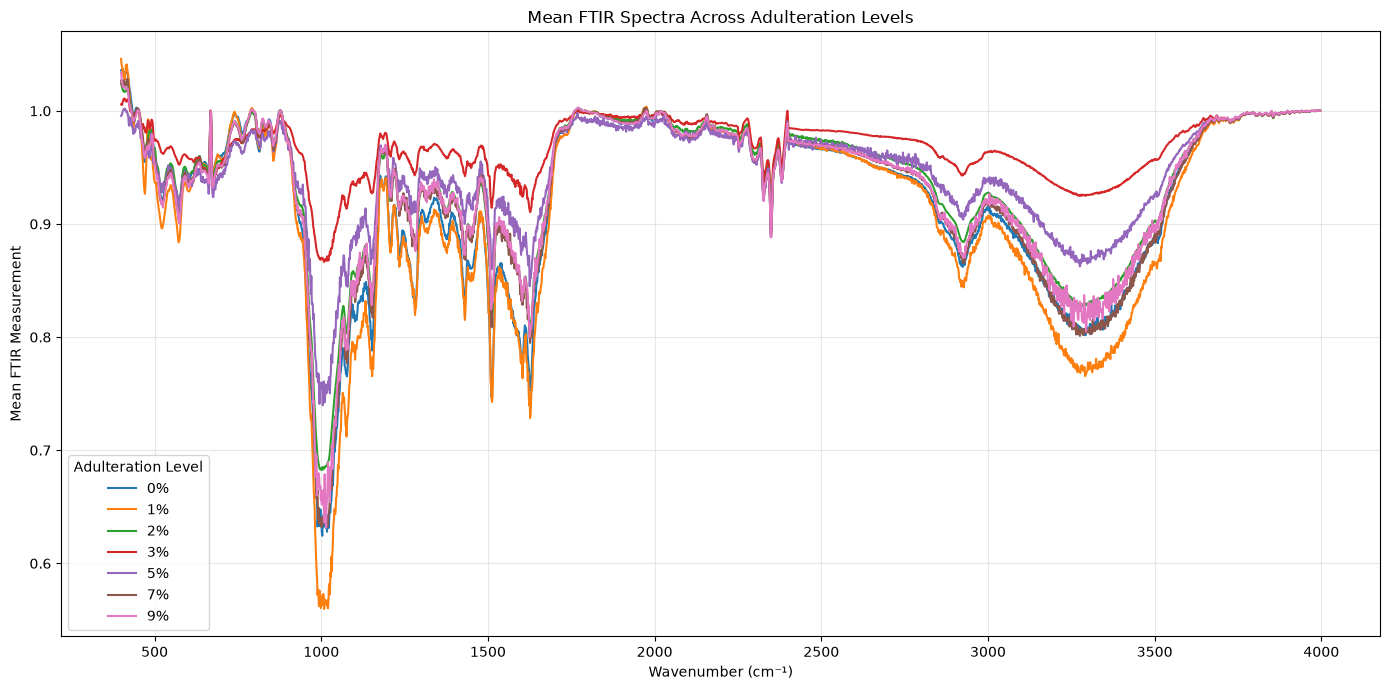

In [1978]:
plt.figure(figsize=(14, 7))

for level in ftir_mean_spectra.index:
    plt.plot(
        wavenumbers,
        ftir_mean_spectra.loc[level].values,
        label=f"{level:g}%"
    )

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Mean FTIR Measurement")
plt.title("Mean FTIR Spectra Across Adulteration Levels")

plt.legend(title="Adulteration Level")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The most prominent regions include approximately:

~900–1100 cm⁻¹
~1200–1700 cm⁻¹
~2800–3500 cm⁻¹

These regions therefore deserve further investigation.

2. The ~1000 cm⁻¹ region is particularly prominent

There is a strong absorption/decrease in the FTIR measurement around ~1000 cm⁻¹.

However, the curves don't follow a perfectly ordered sequence from 0% → 9%.

For example, some intermediate adulteration levels show deeper responses than higher levels.

3. The ~2800–3500 cm⁻¹ region also shows separation

The curves diverge noticeably around the broad feature near ~3200–3400 cm⁻¹.

Again, the separation isn't perfectly monotonic with adulteration.

🧠 This is actually important

Our color modality showed a fairly smooth relationship:

Adulteration ↑
       ↓
Color measurements generally change smoothly

FTIR is more complex:

Adulteration
     ↓
Changes in spectral shape
     ↓
Different wavenumber regions respond differently
     ↓
Relationship may be nonlinear / multivariate

### 5.6 Correlation Between FTIR Measurements and Adulteration

To investigate the relationship between individual FTIR measurements and adulteration percentage, Pearson correlation coefficients are calculated for each wavenumber.

This provides an exploratory view of which spectral regions show stronger linear associations with adulteration.

Because FTIR contains thousands of highly related spectral measurements, these correlations are not treated as final feature-selection criteria.

The analysis is intended to identify potentially informative spectral regions for further investigation.

In [1979]:
# Calculate Pearson correlation between each FTIR wavenumber
# and the adulteration percentage

ftir_correlations = {}

for wavenumber in ftir_spectral_columns:
    ftir_correlations[float(wavenumber)] = ftir[
        wavenumber
    ].corr(
        ftir["Adulteration_Percent"]
    )

ftir_correlations = pd.Series(ftir_correlations) #Converts the dictionary into a Pandas Series, where the index represents the wavenumbers ($\text{cm}^{-1}$) and the values represent the Pearson correlation coefficients ($r$).

print(ftir_correlations.head())
print("\nNumber of correlations:", len(ftir_correlations))

399.47297   -0.176017
400.89966   -0.241390
402.32635   -0.288563
403.75304   -0.307595
405.17973   -0.285336
dtype: float64

Number of correlations: 2522


This confirms the FTIR correlation calculation worked correctly for all 2,522 wavenumbers.

The first few values are:

399.47 cm⁻¹ → −0.176
400.90 cm⁻¹ → −0.241
402.33 cm⁻¹ → −0.289
403.75 cm⁻¹ → −0.308
405.18 cm⁻¹ → −0.285

So unlike the color wavelength analysis, FTIR correlations can be positive or negative depending on the spectral region.

### 5.6.1 FTIR Correlation Profile

The Pearson correlation coefficients are plotted against wavenumber to visualize how the linear association between FTIR measurements and adulteration changes across the spectrum.

Positive correlations indicate that the FTIR measurement tends to increase with adulteration, while negative correlations indicate that it tends to decrease.

The purpose of this analysis is to identify spectral regions with relatively strong associations rather than to select final model features.

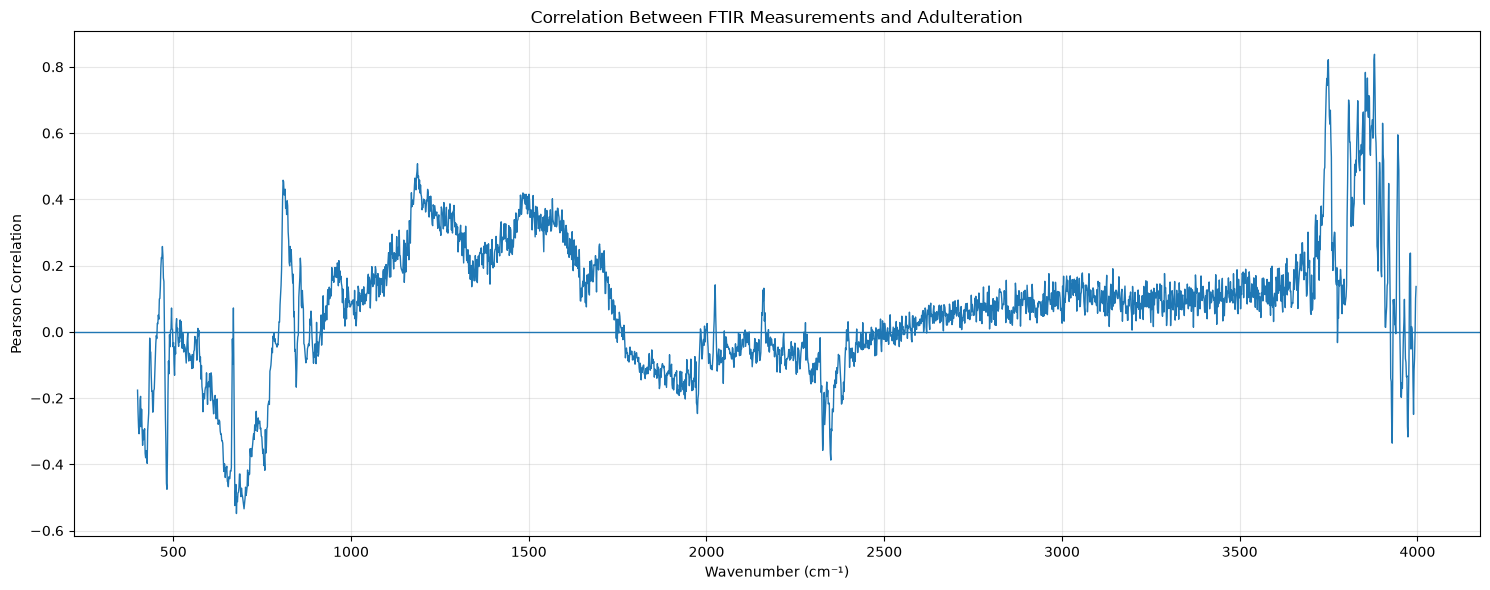

In [1980]:
plt.figure(figsize=(15, 6))

plt.plot(
    ftir_correlations.index,
    ftir_correlations.values,
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Pearson Correlation")
plt.title("Correlation Between FTIR Measurements and Adulteration")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

🔵 Negative correlation regions

Roughly 500–750 cm⁻¹ shows strong negative correlations.
Another weaker negative region appears around ~1800–2500 cm⁻¹.

🔴 Positive correlation regions

A prominent positive region appears around ~1000–1700 cm⁻¹, with some correlations reaching roughly 0.4–0.5.
A particularly strong positive region appears near ~3700–3900 cm⁻¹, where correlations reach approximately 0.8 in parts of the spectrum.

⚪ Near-zero region

A large portion around ~2500–3600 cm⁻¹ has relatively weak positive correlations.

### 5.7 Strongest FTIR Wavenumbers

The FTIR correlation profile contains both positive and negative associations with adulteration percentage.

We now rank the wavenumbers by absolute correlation to identify the measurements showing the strongest linear associations.

Both the correlation coefficient and its direction are retained because positive and negative relationships may contain different information.

This ranking is exploratory and will not be treated as final feature selection.

In [1981]:
# Rank FTIR wavenumbers by absolute correlation

top_ftir_wavenumbers = (
    ftir_correlations
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

top_ftir_table = pd.DataFrame({
    "Wavenumber_cm-1": top_ftir_wavenumbers.index,
    "Correlation": ftir_correlations.loc[
        top_ftir_wavenumbers.index
    ].values,
    "Absolute_Correlation": top_ftir_wavenumbers.values
})

print(top_ftir_table.to_string(index=False))

 Wavenumber_cm-1  Correlation  Absolute_Correlation
      3879.16792     0.837917              0.837917
      3749.33920     0.821668              0.821668
      3877.74123     0.819055              0.819055
      3747.91252     0.815225              0.815225
      3853.48752     0.783259              0.783259
      3859.19427     0.766305              0.766305
      3745.05914     0.765036              0.765036
      3746.48583     0.744664              0.744664
      3750.76589     0.743232              0.743232
      3880.59461     0.738323              0.738323
      3743.63245     0.734210              0.734210
      3863.47434     0.712907              0.712907
      3864.90103     0.707453              0.707453
      3806.40677     0.699848              0.699848
      3832.08718     0.697628              0.697628
      3807.83346     0.680562              0.680562
      3857.76758     0.676655              0.676655
      3742.20576     0.672733              0.672733
      3876.3

5.7 Interpretation — Strongest FTIR Wavenumbers

The top 20 correlations are all positive, with the strongest around the ~3740–3880 cm⁻¹ region.

The strongest is:

3879.17 cm⁻¹ → r = 0.838

followed by:

3749.34 cm⁻¹ → 0.822
3877.74 cm⁻¹ → 0.819
3747.91 cm⁻¹ → 0.815
3853.49 cm⁻¹ → 0.783
📌 Important observation

The top correlations aren't scattered randomly across the spectrum. They are clustered heavily around ~3740–3880 cm⁻¹.

## 5.8 FTIR Feature Redundancy

The FTIR dataset contains 2522 spectral measurements for each sample.

Because neighboring wavenumbers often exhibit similar spectral behavior, many FTIR features may be strongly correlated with one another.

We examine the feature-to-feature correlation structure to understand the degree of redundancy within the FTIR data.

This analysis will help inform later preprocessing and dimensionality-reduction decisions.

### 5.8.1 FTIR Correlation Heatmap

A subset of the FTIR features is visualized using a correlation heatmap.

Because the full 2522 × 2522 correlation matrix is computationally expensive and difficult to interpret visually, a representative subset of wavenumbers is used for exploratory visualization.

In [1982]:
# Select a representative subset of FTIR features

ftir_subset_columns = ftir_spectral_columns[::50] #to select every 50th feature (wavenumber column) from ftir_spectral_columns.

print("Selected FTIR features:", len(ftir_subset_columns))

ftir_subset_correlation = ftir[
    ftir_subset_columns
].corr()

print("Correlation matrix shape:", ftir_subset_correlation.shape)

Selected FTIR features: 51
Correlation matrix shape: (51, 51)


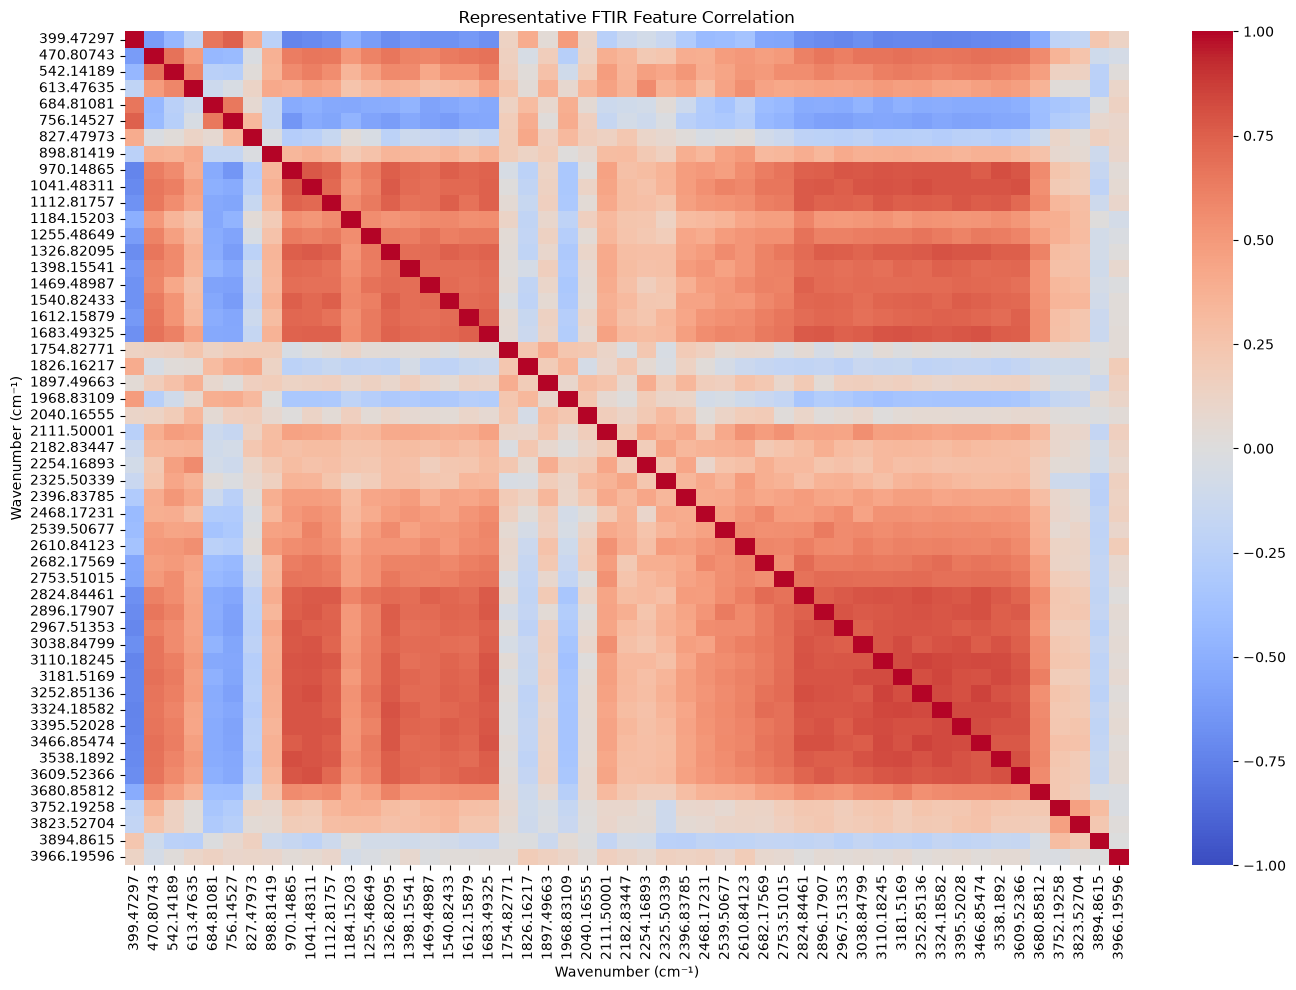

In [1983]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    ftir_subset_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Representative FTIR Feature Correlation")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Wavenumber (cm⁻¹)")

plt.tight_layout()
plt.show()

5.8.1 Interpretation — FTIR Feature Redundancy

A few important patterns are visible:

Large red regions indicate groups of wavenumbers with strong positive correlation.
Several broad regions contain highly correlated measurements rather than isolated independent features.
Some blue regions indicate negative relationships between particular spectral regions.
The diagonal is 1.0, as expected, because each feature is perfectly correlated with itself.
🧠 Main takeaway

The 2,522 FTIR measurements contain considerable redundancy.

So later, rather than assuming:

2522 features = 2522 independent pieces of information

we should treat the FTIR data as a high-dimensional, highly structured spectral signal.

This supports investigating methods such as:

dimensionality reduction such as PCA
regularization
spectral preprocessing
carefully validated feature selection

But we won't remove features based on this heatmap alone.

## 5.9 FTIR Data Quality Check

Before moving to the image-derived features, we perform a final data-quality check on the FTIR measurements.

The analysis checks:

- missing spectral values
- missing target values
- duplicate Sample IDs
- extreme observations across the spectral measurements

The purpose is to identify potential data-quality issues without automatically removing unusual spectra.

In [1984]:
# FTIR data-quality checks

print("Missing spectral values:",
      ftir[ftir_spectral_columns].isna().sum().sum())

print("Missing adulteration values:",
      ftir["Adulteration_Percent"].isna().sum())

print("Duplicate Sample IDs:",
      ftir["Sample ID"].duplicated().sum())

print("Number of samples:",
      len(ftir))

Missing spectral values: 0
Missing adulteration values: 0
Duplicate Sample IDs: 0
Number of samples: 350


Our key FTIR findings

350 physical samples

2522 FTIR spectral features

Strong spectral variation occurs across several wavenumber regions.

The ~3740–3880 cm⁻¹ region showed the strongest individual correlations with adulteration, with the highest around r = 0.8379.

Other regions showed both positive and negative associations.

FTIR features exhibit substantial correlation/redundancy.

No missing spectral values or duplicate Sample IDs were found

-----------------------------------------------------------------------------

# 6. EfficientNet-B0 Image Feature Analysis

The image modality is represented using precomputed EfficientNet-B0 features.

Each of the 350 turmeric samples is represented by a 1280-dimensional feature vector extracted from the corresponding image.

Unlike the Hunter Lab and FTIR measurements, these features are learned representations produced by a deep neural network and do not have direct physical interpretations at the individual-feature level.

The objectives of this analysis are to:

- understand the structure of the image feature dataset
- inspect feature distributions and variability
- identify missing or unusual feature values
- investigate relationships between image features and adulteration
- examine whether the learned feature space contains visible class structure

No image classification model is trained in this section.

### 6.1 EfficientNet-B0 Dataset Structure

We first inspect the dimensions and structure of the precomputed image feature dataset.

The dataset should contain one Sample ID column, 1280 EfficientNet-B0 features, and the adulteration target.

In [1985]:
print("EfficientNet-B0 shape:", efficientnet.shape)

print("\nFirst 10 columns:")
print(efficientnet.columns[:10].tolist())

print("\nLast 5 columns:")
print(efficientnet.columns[-5:].tolist())

EfficientNet-B0 shape: (350, 1282)

First 10 columns:
['Sample_ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9']

Last 5 columns:
['Feature_1277', 'Feature_1278', 'Feature_1279', 'Feature_1280', 'Target']


### 6.2 Inspecting EfficientNet-B0 Feature Values

Each turmeric sample is represented by 1280 learned image features extracted using EfficientNet-B0.

Because these features are learned representations rather than directly measurable physical quantities, we first inspect their numerical values and basic structure.

This helps verify that the feature matrix is suitable for further exploratory analysis.

In [1986]:
# Inspect the first few EfficientNet-B0 feature values

print(
    efficientnet.iloc[:5, :8] #df.iloc[row_position, column_position]
)

  Sample_ID  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0     T0S01  -0.149074  -0.047830  -0.024970  -0.090157  -0.026123   0.197063   
1     T0S02  -0.125764  -0.040440  -0.041863  -0.095619   0.055201   0.302645   
2     T0S03  -0.137168  -0.046979  -0.050521  -0.126286   0.008802   0.120511   
3     T0S04  -0.148400  -0.042673  -0.073778  -0.114719   0.023353   0.346130   
4     T0S05  -0.140647  -0.045826  -0.028092  -0.110010   0.015048   0.284736   

   Feature_7  
0  -0.191883  
1  -0.194103  
2  -0.193411  
3  -0.191926  
4  -0.196062  


6.2 Interpretation

The EfficientNet-B0 features are:

numerical floating-point values
represented as learned feature embeddings
different features can have both positive and negative values
no obvious issue is visible in the inspected values

In [1987]:
efficientnet_feature_columns = [
    col for col in efficientnet.columns
    if col not in ["Sample_ID", "Target"]
]

print("Number of image features:", len(efficientnet_feature_columns))

print(
    "Missing feature values:",
    efficientnet[efficientnet_feature_columns].isna().sum().sum()
)

print(
    "Duplicate Sample IDs:",
    efficientnet["Sample_ID"].duplicated().sum()
)

print(
    "Feature data types:",
    efficientnet[efficientnet_feature_columns]
    .dtypes
    .value_counts()
)

Number of image features: 1280
Missing feature values: 0
Duplicate Sample IDs: 0
Feature data types: float64    1280
Name: count, dtype: int64


### 6.3 EfficientNet-B0 Feature Distribution and Variance

The EfficientNet-B0 representation contains 1280 learned features.

Because individual features do not have direct physical interpretations, we examine their statistical distributions and variance to understand how much information is present across the feature dimensions.

Features with extremely low variance may contribute little to distinguishing samples and can be considered during later preprocessing.

In [1988]:
# Calculate summary statistics for all EfficientNet features

efficientnet_feature_stats = efficientnet[
    efficientnet_feature_columns
].describe().T
#.describe(): Calculates standard descriptive statistics for each column: count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile, and maximum.
#.T (Transpose): Flips the table rows and columns. Instead of having statistics as rows and 1,280 features stretching across columns, each feature gets its own row, and the summary statistics become columns.
print(
    efficientnet_feature_stats[
        ["mean", "std", "min", "max"]
    ].head(10)
)

                mean       std       min       max
Feature_1  -0.128573  0.038063 -0.207000  0.027215
Feature_2  -0.046186  0.009790 -0.084896 -0.028724
Feature_3  -0.012171  0.054675 -0.153511  0.194580
Feature_4  -0.069885  0.058466 -0.162045  0.097504
Feature_5   0.026899  0.087942 -0.130666  0.370044
Feature_6   0.178558  0.127450 -0.152695  0.560101
Feature_7  -0.158385  0.045731 -0.214550  0.090883
Feature_8   0.165593  0.187555 -0.107665  0.696637
Feature_9   0.014812  0.083001 -0.154658  0.305335
Feature_10 -0.177240  0.023290 -0.236018 -0.092619


The first 10 features show that the learned embeddings have different scales and ranges.

For example:

Feature_1: std ≈ 0.038
Feature_6: std ≈ 0.127
Feature_8: std ≈ 0.188
Some features are mostly negative, while others span both negative and positive values.

This confirms an important point:

EfficientNet features are heterogeneous learned representations with different levels of variation.

We therefore shouldn't assume that every feature contributes equally.

### 6.3.1 Feature Variance

We calculate the variance of each EfficientNet-B0 feature to determine how much each feature varies across the 350 samples.

Very low-variance features contain little variation across the dataset and may provide limited discriminatory information.

In [1989]:
# Calculate variance of each image feature

efficientnet_variance = (
    efficientnet[efficientnet_feature_columns]
    .var()
    .sort_values()
)

print("Lowest-variance features:")
print(efficientnet_variance.head(10))

print("\nHighest-variance features:")
print(efficientnet_variance.tail(10))

Lowest-variance features:
Feature_534     0.000010
Feature_228     0.000017
Feature_674     0.000021
Feature_1050    0.000029
Feature_287     0.000032
Feature_808     0.000038
Feature_826     0.000039
Feature_399     0.000047
Feature_345     0.000049
Feature_1190    0.000050
dtype: float64

Highest-variance features:
Feature_266     0.130414
Feature_1249    0.131903
Feature_1273    0.138532
Feature_537     0.150952
Feature_423     0.155295
Feature_599     0.160799
Feature_154     0.164446
Feature_566     0.178118
Feature_1027    0.267766
Feature_693     0.278944
dtype: float64


### 6.3.2 Distribution of EfficientNet-B0 Feature Variance

The variance of each EfficientNet-B0 feature is visualized to examine how variability is distributed across the 1280-dimensional feature space.

This visualization helps identify whether only a small number of features have substantial variation or whether variability is distributed across many feature dimensions.

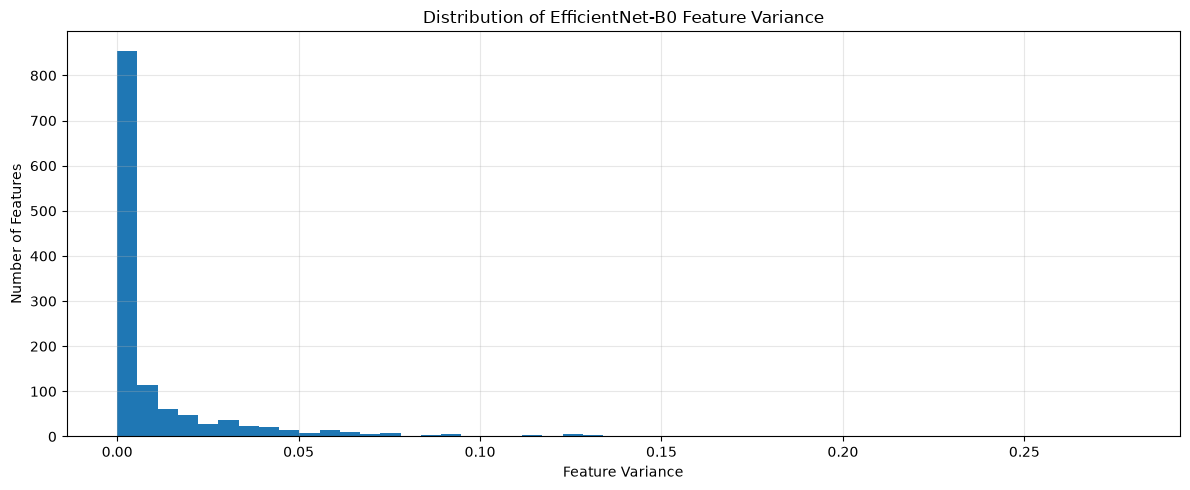

In [1990]:
plt.figure(figsize=(12, 5))

plt.hist(
    efficientnet_variance,
    bins=50 #Divides the range from the lowest variance (~0.00001) to the highest variance (~0.279) into 50 equal interval bins to show how many features fall into each variance range.
)

plt.xlabel("Feature Variance")
plt.ylabel("Number of Features")
plt.title("Distribution of EfficientNet-B0 Feature Variance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

6.3.2 Interpretation

The distribution is strongly right-skewed:

A very large number of EfficientNet features have low variance, clustered close to 0.
A smaller number have moderate variance.
Only a few features have very high variance, extending up to roughly 0.28.

So the 1280-dimensional representation is not uniformly variable across feature dimensions.

In [1991]:
# Count features below different variance thresholds

thresholds = [0.0001, 0.001, 0.01, 0.05]

for threshold in thresholds:
    count = (efficientnet_variance < threshold).sum() #Creates a Boolean Series (True/False) indicating whether each of the 1,280 feature variances is smaller than the current threshold.

    print(
        f"Variance < {threshold}: "
        f"{count} features "
        f"({count / len(efficientnet_variance) * 100:.2f}%"
    )

Variance < 0.0001: 39 features (3.05%
Variance < 0.001: 547 features (42.73%
Variance < 0.01: 955 features (74.61%
Variance < 0.05: 1198 features (93.59%


🧠 What this tells us

A large majority of the learned features have relatively low variance:

74.61% of features have variance below 0.01.

But remember ⚠️:

Low variance ≠ unimportant.

### 6.4 Relationship Between EfficientNet-B0 Features and Adulteration

We now examine the relationship between each EfficientNet-B0 feature and the adulteration percentage.

Pearson correlation is used as an exploratory measure of linear association.

The purpose is to identify whether particular learned image features show stronger statistical relationships with adulteration.

Correlation does not establish causation or guarantee predictive usefulness. Final feature importance will be evaluated using validated machine-learning models.

In [1992]:
# Calculate correlation between each EfficientNet feature
# and adulteration percentage

efficientnet_correlations = (
    efficientnet[efficientnet_feature_columns]
    .corrwith(efficientnet["Target"])
    .sort_values()
)

print("Number of correlations:", len(efficientnet_correlations))

print("\nMost negative correlations:")
print(efficientnet_correlations.head(10))

print("\nMost positive correlations:")
print(efficientnet_correlations.tail(10))

Number of correlations: 1280

Most negative correlations:
Feature_1273   -0.612833
Feature_1181   -0.577316
Feature_253    -0.575615
Feature_514    -0.571487
Feature_53     -0.563224
Feature_761    -0.536921
Feature_324    -0.534558
Feature_747    -0.534453
Feature_19     -0.528953
Feature_947    -0.519833
dtype: float64

Most positive correlations:
Feature_1020    0.542578
Feature_845     0.545478
Feature_44      0.551425
Feature_1012    0.561968
Feature_1053    0.586574
Feature_301     0.594288
Feature_887     0.600846
Feature_1172    0.601004
Feature_559     0.601341
Feature_398     0.620902
dtype: float64


EfficientNet-B0
      ↓
1280 learned features
      ↓
Some features ↑ with adulteration
Some features ↓ with adulteration
      ↓
Image representation contains
measurable information related to adulteration

### 6.4.1 EfficientNet-B0 Feature Correlation Profile

The correlation coefficients between the 1280 EfficientNet-B0 features and adulteration percentage are visualized to examine the overall distribution of feature–target associations.

Both positive and negative correlations are retained because either direction may contain useful information about adulteration.

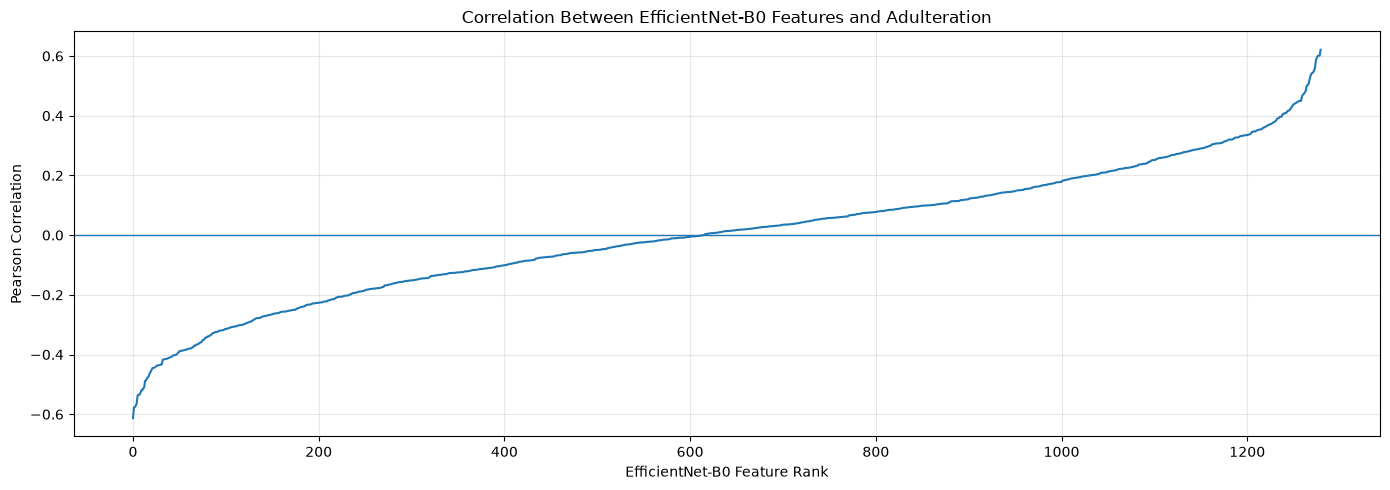

In [1993]:
plt.figure(figsize=(14, 5))

plt.plot(
    range(len(efficientnet_correlations)),
    efficientnet_correlations.values
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("EfficientNet-B0 Feature Rank")
plt.ylabel("Pearson Correlation")
plt.title(
    "Correlation Between EfficientNet-B0 Features and Adulteration"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

6.4.1 Interpretation

The correlation profile shows a smooth spread from negative to positive values:

Strongest negative correlation ≈ −0.61
Many features have weak/moderate correlations around zero
Strongest positive correlation ≈ +0.62

So the image representation contains both positively and negatively associated feature dimensions.

6.4.1 Interpretation

The correlation profile shows a smooth spread from negative to positive values:

Strongest negative correlation ≈ −0.61
Many features have weak/moderate correlations around zero
Strongest positive correlation ≈ +0.62

So the image representation contains both positively and negatively associated feature dimensions.

In [1994]:
# Rank EfficientNet features by absolute correlation

top_image_features = (
    efficientnet_correlations
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

top_image_table = pd.DataFrame({
    "Feature": top_image_features.index,
    "Correlation": efficientnet_correlations.loc[
        top_image_features.index
    ].values,
    "Absolute_Correlation": top_image_features.values
})

print(
    top_image_table.to_string(index=False)
)

     Feature  Correlation  Absolute_Correlation
 Feature_398     0.620902              0.620902
Feature_1273    -0.612833              0.612833
 Feature_559     0.601341              0.601341
Feature_1172     0.601004              0.601004
 Feature_887     0.600846              0.600846
 Feature_301     0.594288              0.594288
Feature_1053     0.586574              0.586574
Feature_1181    -0.577316              0.577316
 Feature_253    -0.575615              0.575615
 Feature_514    -0.571487              0.571487
  Feature_53    -0.563224              0.563224
Feature_1012     0.561968              0.561968
  Feature_44     0.551425              0.551425
 Feature_845     0.545478              0.545478
Feature_1020     0.542578              0.542578
 Feature_992     0.540917              0.540917
 Feature_761    -0.536921              0.536921
 Feature_324    -0.534558              0.534558
 Feature_747    -0.534453              0.534453
Feature_1022     0.532431              0

🧠 Interpretation

The strongest feature is:

Feature_398 → r = +0.621

followed by:

Feature_1273 → r = −0.613
Feature_559 → r = +0.601
Feature_1172 → r = +0.601
Feature_887 → r = +0.600

The top features contain both positive and negative relationships, which is useful evidence that the learned image representation captures different aspects of the samples associated with adulteration.

### 6.6 PCA Visualization of EfficientNet-B0 Features

The EfficientNet-B0 representation contains 1280 dimensions, which cannot be directly visualized.

Principal Component Analysis (PCA) is used to project the high-dimensional feature space into two dimensions while preserving as much variance as possible.

The resulting two-dimensional representation is colored according to adulteration level.

This visualization helps us explore whether samples with different adulteration levels form distinguishable patterns in the learned image feature space.

PCA is used here only for visualization and exploratory analysis, not as a final modeling step.

In [1995]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Extract image features
X_image = efficientnet[efficientnet_feature_columns]

# Standardize features before PCA
scaler = StandardScaler() # Why this is necessary: PCA is sensitive to differences in feature scales and variances.What it does: Centers each feature column to a mean of $0$ and scales it to a variance of $1$ ($z$-score normalization). This prevents high-variance features from artificially dominating the principal component directions.

X_image_scaled = scaler.fit_transform(X_image)

# Reduce to two principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_image_scaled)

#Fits a PCA model to project the high-dimensional ($1,280$ dimensions) standardized data down to just 2 principal components (PC1 and PC2).X_pca becomes a 2D array holding the coordinates of each sample along these two primary directions of maximum variance.

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.24302191 0.1378324 ]
Total variance explained: 0.38085431486282567


### 6.6.1 PCA Scatter Plot

The two principal components are plotted and colored according to adulteration level.

If samples from different adulteration levels occupy different regions of the projected space, this provides exploratory evidence that the image representation contains class-related structure.

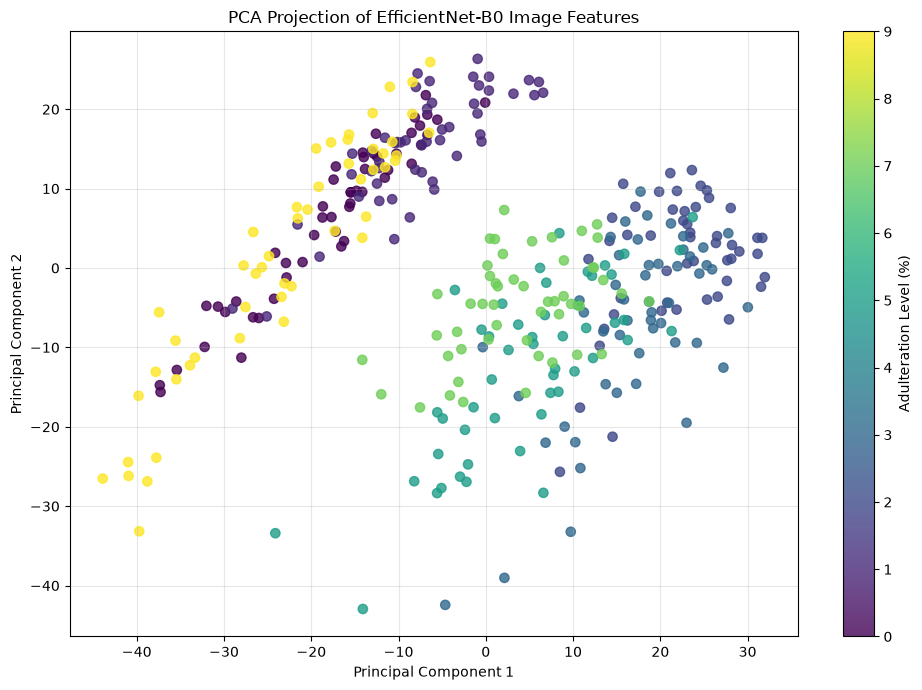

In [1996]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=efficientnet["Target"],
    cmap="viridis",
    s=45,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "PCA Projection of EfficientNet-B0 Image Features"
)

plt.colorbar(
    scatter,
    label="Adulteration Level (%)"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

6.6 Interpretation — PCA Projection

There is clearly structure in the EfficientNet-B0 feature space.

What we can see

The samples are not randomly scattered.

There appears to be a broad progression across the PCA space:

Some adulteration levels concentrate toward the upper-left region.
Other levels are more concentrated toward the right/lower region.
There is also noticeable overlap between several neighboring adulteration levels.

This is particularly interesting for FoodSure AI because we're not only interested in detecting:

adulterated vs. non-adulterated

but also in estimating the adulteration percentage.

The PCA visualization suggests that the learned image representation contains class-related structure, although the classes are not perfectly separated.

### 6.6.2 PCA Explained Variance

The explained variance ratio indicates the proportion of total standardized feature variance captured by each principal component.

This provides context for interpreting the two-dimensional PCA visualization.

In [1997]:
print(
    "PC1 explained variance:",
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    "PC2 explained variance:",
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    "Total explained variance:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

PC1 explained variance: 24.30%
PC2 explained variance: 13.78%
Total explained variance: 38.09%


🧠 Interpretation
PC1: 24.30%
PC2: 13.78%
PC1 + PC2: 38.09%

So our 2D visualization represents about 38.09% of the total variance in the standardized 1280-dimensional EfficientNet feature space.

That means the PCA plot is useful for seeing broad structure, but 61.91% of the variance remains in the other principal components.

Therefore, our earlier observation of class-related structure is meaningful as an exploratory finding, but the 2D plot doesn't represent the entire image feature space.

### Interpretation

The first principal component explains 24.30% of the total variance, while the second explains 13.78%.

Together, the first two components explain 38.09% of the variance in the standardized EfficientNet-B0 feature space.

The PCA projection therefore provides a useful two-dimensional view of the major structure in the image embeddings, but it does not capture the complete feature space.

The visible organization of adulteration levels suggests that the learned image representation contains class-related structure, although overlap between levels remains.

### 6.7 EfficientNet Feature Behavior Across Adulteration Levels

Correlation measures a linear relationship between an individual feature and adulteration percentage.

However, the dataset contains seven discrete adulteration levels.

We therefore examine selected high-correlation EfficientNet-B0 features across the seven levels to determine whether their distributions show systematic differences.

Only a small number of representative features are visualized because plotting all 1280 features would not be informative.

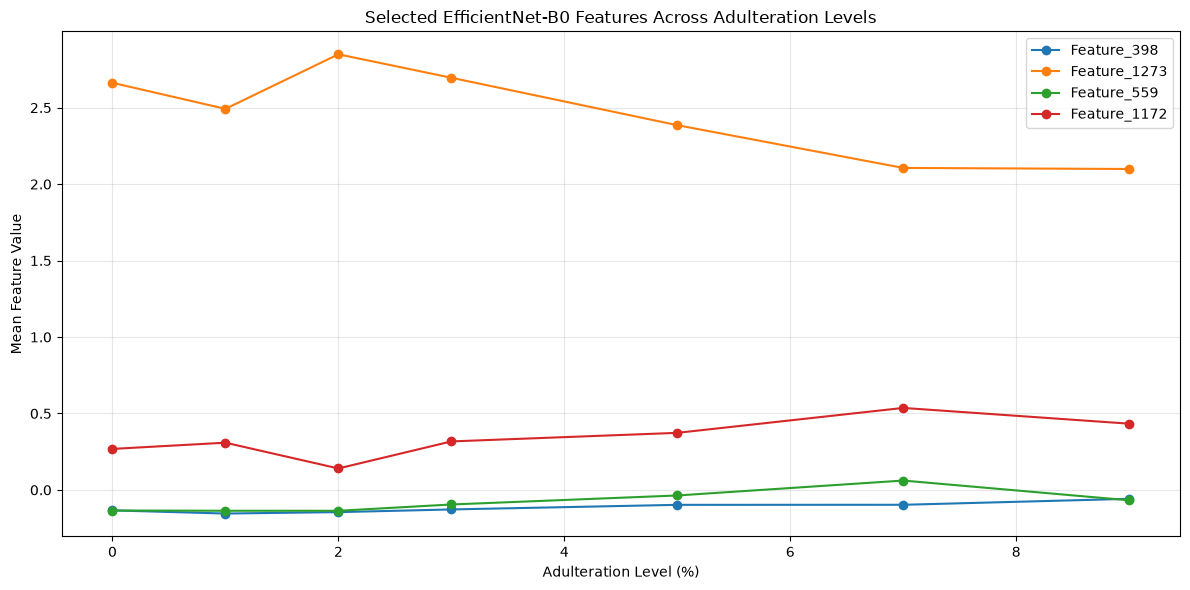

In [1998]:
selected_image_features = [
    "Feature_398",
    "Feature_1273",
    "Feature_559",
    "Feature_1172"
]

plt.figure(figsize=(12, 6))

for feature in selected_image_features:
    means = ( #Groups the data by the discrete adulteration levels (0%, 1%, 2%, 3%, 5%, 7%, 9%) and calculates the mean embedding value of the feature for each group.
        efficientnet
        .groupby("Target")[feature]
        .mean()
        .reindex([0, 1, 2, 3, 5, 7, 9]) #Enforces the strict chronological/percentage order of your discrete targets along the x-axis.
    )

    plt.plot(
        means.index,
        means.values,
        marker="o",
        label=feature
    )

plt.xlabel("Adulteration Level (%)")
plt.ylabel("Mean Feature Value")
plt.title(
    "Selected EfficientNet-B0 Features Across Adulteration Levels"
)
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

6.7 Interpretation — Selected Image Features

We can see that the selected features behave differently across adulteration levels:

Feature_1273 generally decreases as adulteration increases, although there are local fluctuations.
Feature_1172 shows an overall increase from the lower to higher adulteration levels, again with some fluctuations.
Feature_559 also changes across the levels, with a more gradual pattern.
Feature_398 changes relatively little compared with the others.

This is consistent with our correlation analysis:

Feature_1273 → r = -0.613
Feature_398  → r = +0.621
Feature_559  → r = +0.601
Feature_1172 → r = +0.601

-----------------------------------------------------------------------------

# 7. Cross-Modality Analysis

The dataset contains three complementary modalities:

1. Color measurements
2. FTIR spectroscopy
3. Image-derived EfficientNet-B0 features

Each modality captures different characteristics of the turmeric samples.

This section compares the exploratory findings across modalities to understand whether they provide similar or complementary information about adulteration.

The analysis is descriptive and exploratory. Final conclusions about predictive performance will be made only after supervised model evaluation.

### 7.1.1 Modality Dimensions

We first compare the number of features available from each modality.

This provides an overview of the relative dimensionality of the three data sources.

In [1999]:
modality_dimensions = pd.DataFrame({
    "Modality": [
        "Color",
        "FTIR",
        "EfficientNet-B0"
    ],
    "Number_of_Features": [
        46,
        2522,
        1280
    ],
    "Samples": [
        350,
        350,
        350
    ]
})

print(modality_dimensions)

          Modality  Number_of_Features  Samples
0            Color                  46      350
1             FTIR                2522      350
2  EfficientNet-B0                1280      350


### 7.1.2 Strongest Feature–Adulteration Relationships

The strongest observed correlations from each modality are compared to understand how strongly individual measurements or learned features are associated with adulteration percentage.

These values are descriptive and should not be interpreted as final feature importance.

In [2000]:
# Strongest Color correlation
color_corr = color[
    ["L*", "a*", "b*"]
].corrwith(
    color["Adulteration_Percent"]
).abs().sort_values(ascending=False)

# Strongest FTIR correlation
ftir_max_corr = ftir_correlations.abs().max()

# Strongest EfficientNet correlation
image_max_corr = efficientnet_correlations.abs().max()

print("Strongest Color correlation:")
print(color_corr)

print("\nStrongest absolute FTIR correlation:") #Refers to the pre-calculated Series of correlations across all 1,280 deep learning feature dimensions.
print(ftir_max_corr)

print("\nStrongest absolute EfficientNet correlation:") #EfficientNet provides learned spatial visual feature representations
print(image_max_corr)

Strongest Color correlation:
a*    0.943219
L*    0.925670
b*    0.911491
dtype: float64

Strongest absolute FTIR correlation:
0.8379169314330566

Strongest absolute EfficientNet correlation:
0.6209024897801512


### 7.3 Cross-Modality Sample Alignment

Multimodal analysis requires each observation from one modality to correspond to the same physical sample in the other modalities.

We therefore verify that the Sample IDs are identical across the FTIR, Color, and EfficientNet-B0 datasets.

Correct sample alignment is essential before any feature-level multimodal fusion is performed.

In [2001]:
ftir_ids = set(ftir["Sample ID"])

color_ids = set(color["Sample_ID"])

image_ids = set(efficientnet["Sample_ID"])

print("FTIR samples:", len(ftir_ids))
print("Color samples:", len(color_ids))
print("Image samples:", len(image_ids))

print("\nFTIR = Color:", ftir_ids == color_ids)
print("FTIR = Image:", ftir_ids == image_ids)
print("Color = Image:", color_ids == image_ids)

FTIR samples: 350
Color samples: 350
Image samples: 350

FTIR = Color: True
FTIR = Image: True
Color = Image: True


# 8. Exploratory Data Analysis — Final Conclusions

The exploratory analysis provided several important observations about the FoodSure AI dataset.

### Dataset Structure

- The dataset contains 350 physical turmeric samples.
- Seven controlled adulteration levels are present: 0%, 1%, 2%, 3%, 5%, 7%, and 9%.
- Each adulteration level contains 50 samples.
- The FTIR, Color, and EfficientNet-B0 datasets are aligned through Sample ID.

### Color Modality

- The Hunter Lab measurements show systematic changes across adulteration levels.
- L* and b* show strong positive relationships with adulteration percentage.
- a* shows a strong negative relationship with adulteration percentage.
- Distribution analysis shows that the color measurements vary across adulteration groups, although some overlap remains.
- The wavelength measurements also show strong relationships with adulteration, particularly around the 480–570 nm region.

### FTIR Modality

- FTIR contains 2,522 spectral features for each sample.
- The spectra show characteristic changes across adulteration levels.
- Several wavenumber regions exhibit substantial correlation with adulteration percentage.
- Strong feature-to-feature correlations indicate considerable redundancy within the spectral measurements.
- The high dimensionality of FTIR relative to the number of samples creates a potential overfitting risk.

### Image Modality

- EfficientNet-B0 provides 1,280 learned image features per sample.
- Feature variances differ substantially across the embedding dimensions.
- Several learned features show measurable relationships with adulteration percentage.
- PCA revealed visible structure associated with adulteration levels.
- The first two principal components explain 38.09% of the standardized feature variance.
- Considerable overlap remains between some adulteration levels.

### Cross-Modality Findings

The three modalities capture different aspects of the turmeric samples:

- Color captures physical color characteristics.
- FTIR captures spectral characteristics.
- EfficientNet-B0 captures learned visual representations.

All three modalities contain information associated with adulteration, but they differ substantially in dimensionality and feature structure.

These findings motivate controlled experiments using individual modalities as well as multimodal combinations.

### Modeling Implications

The EDA suggests several considerations for the modeling stage:

1. Feature scaling will be important for many machine-learning algorithms.
2. FTIR and EfficientNet-B0 are high-dimensional relative to the number of samples.
3. Feature selection or dimensionality reduction may be investigated where appropriate.
4. Multimodal fusion must preserve Sample ID alignment.
5. All preprocessing operations that learn parameters must be fitted only on training data to avoid data leakage.
6. Evaluation must be performed using sample-level splits so that information from the same physical sample does not appear in both training and test sets.

### Final Note

EDA findings describe patterns present in the dataset but do not establish predictive performance.

The ability of each modality to detect, classify, or quantify adulteration will be evaluated in subsequent supervised machine-learning experiments.

## End of Exploratory Data Analysis

The dataset structure, distributions, feature relationships, spectral behavior, image embeddings, and cross-modality alignment have now been explored.

The next stage is preprocessing and preparation of leakage-safe datasets for supervised machine-learning experiments.